In [118]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
import os
import json
import shutil
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
from numpy.polynomial import Polynomial
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
from matplotlib.lines import Line2D
from scipy.stats import lognorm
from scipy.optimize import curve_fit
import statsmodels.api as sm

from phd_project.config import config
from phd_project.scripts.standardise_responses import standardise_responses
from standes.analysis.recorders import get_recorder, get_recorders

from phd_project.scripts.templates.copy_templates_to_folders import (
    # copy_pushover_config,
    copy_analysis_config,
    copy_structural_model,
    configure_batch_run_file,
    copy_file,
)

from phd_project.scripts.equivalent_sdof import (
    _calculate_participation_factor,
    convert_poc_to_eq_sdof_poc,
)

from phd_project.scripts.WP1_ground_motion_set.optimise_sdof_parameters_differential_evolution import (
    validate_optimised_parameters,
    )

from fitpo import (
    fit_cbf_backbone, 
    fit_envelope, 
    fit_piecewise_backbone,
    fit_tetralinear_backbone
    )

from fitpo.fitting import elastic_slope

cfg = config.load_config()

In [120]:
def _load_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

def _load_cyclic_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "cyclic_pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

def cumulative_distance(d):
    """
    Calculates cumulative absolute displacement.
    i.e. the total distance the roof node travelled
    """
    return np.concatenate(([0], np.cumsum(np.abs(np.diff(d)))))

In [121]:
ROOT = cfg["analysis_data"]["site_influence_investigation"]

In [122]:
site_folders = os.listdir(ROOT)

cpos = {}
ds = {}
for folder in site_folders:
    site = int(folder.split("_")[-1])
    cpo = _load_cyclic_pushover_curve(ROOT / folder / "mdof")
    cd = cumulative_distance(cpo[:, 0])[-1]
    cpos[site] = cpo
    ds[site] = cd

sorted_keys = sorted(cpos.keys())
cpos = {k: cpos[k] for k in sorted_keys}
cds = [ds[k] for k in sorted_keys]

In [123]:
EXPECTED_CD = 6876.4

In [124]:
oks = []
for i, cd in enumerate(cds):
    if cd > 0.95 * EXPECTED_CD:
        oks.append(i)
redos = [s for s in sorted_keys if s not in oks]

print(redos)

[7, 10, 11, 13, 14, 15, 18, 24, 28, 31, 34, 37, 38, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 59]


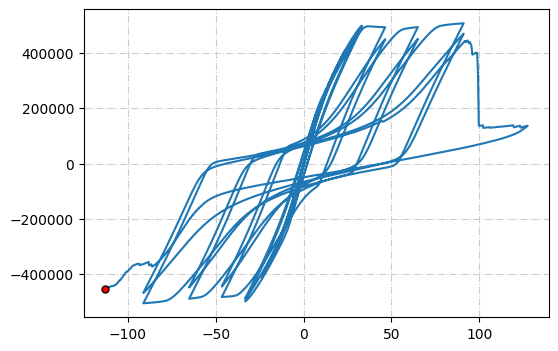

In [125]:
s =13

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cpos[s][:, 0], cpos[s][:, 1], label=f"Site {s}")
ax.plot(cpos[s][-1, 0], cpos[s][-1, 1], "o", markersize=5, ls="none", mfc="r", mec="k")
ax.grid(ls="-.", color="0.8")

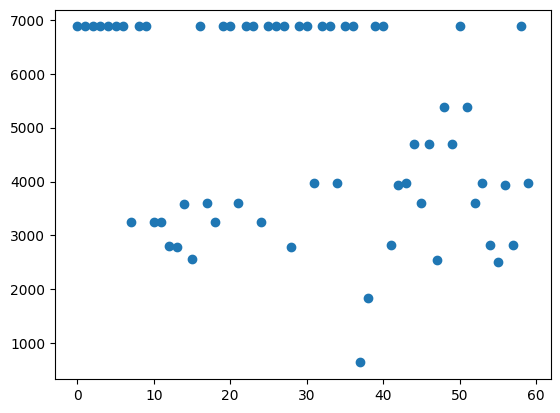

In [44]:
plt.plot(cds, "o", ls="none")

In [50]:
cds[50]

np.float64(6876.398401682788)